# 📊T20 Cricket Analytics: Performance, Strategy & Fan Engagement

## 🎯 Objective
This project performs an end-to-end analysis of a cricket league ecosystem, covering financial growth, match dynamics, team performance, and player valuation.

The goal is to extract actionable insights and identify key drivers of success, engagement, and value.

---

## 🔍 Analysis Scope

### 1. League Growth Analysis
- Revenue trends over time
- Sponsorship and brand value growth

### 2. Match & Engagement Analysis
- Impact of sixes and scoring on viewership
- Match intensity and fan engagement

### 3. Team Performance Analysis
- Win rates and consistency
- Efficiency vs team value

### 4. Player Value Analysis
- Salary vs performance
- Identifying undervalued and overvalued players

### 5. Feature Engineering & Advanced Insights
- Creating new performance metrics
- Correlation analysis

### 6. Predictive Analysis 
- Can match outcomes be predicted?


### Analysis By
- Shubham Kulkarni

In [1]:
import pandas as pd

financial = pd.read_csv("financial_growth.csv")
league = pd.read_csv("league_overview.csv")
matches = pd.read_csv("match_stats.csv")
players = pd.read_csv("player_auction_salary.csv")
season = pd.read_csv("season_performance.csv")
teams = pd.read_csv("team_performance.csv")

In [2]:
financial.head()


,Year,League,Brand_Value_USD_M,Revenue_USD_M,Total_Sponsorship_USD_M,Prize_Pool_INR_Cr,Franchise_Avg_Value_USD_M
0,2016,IPL,521.2,346.9,78.1,35.00,54.0
1,2016,PSL,101.7,33.3,10.0,4.50,14.2
2,2016,BBL,80.8,59.4,21.9,1.76,13.9
3,2017,IPL,824.5,1765.3,136.8,35.00,71.2
4,2017,PSL,127.6,39.3,13.5,5.00,19.4


In [3]:
financial.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       30 non-null     int64  
 1   League                     30 non-null     object 
 2   Brand_Value_USD_M          30 non-null     float64
 3   Revenue_USD_M              30 non-null     float64
 4   Total_Sponsorship_USD_M    30 non-null     float64
 5   Prize_Pool_INR_Cr          30 non-null     float64
 6   Franchise_Avg_Value_USD_M  30 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.8+ KB


In [4]:
financial.describe()

,Year,Brand_Value_USD_M,Revenue_USD_M,Total_Sponsorship_USD_M,Prize_Pool_INR_Cr,Franchise_Avg_Value_USD_M
count,30.000000,30.000000,30.00000,30.000000,30.00000,30.000000
mean,2020.500000,746.866667,2271.26000,130.730000,16.23900,61.166667
std,2.921384,982.014638,3932.66606,170.771126,16.64918,59.815638
min,2016.000000,80.800000,33.30000,10.000000,1.76000,13.900000
25%,2018.000000,141.675000,68.90000,27.125000,4.42500,21.200000
50%,2020.500000,205.900000,103.65000,40.000000,6.52500,31.750000
75%,2023.000000,1048.600000,2797.15000,181.275000,35.00000,84.025000
max,2025.000000,3313.600000,12976.40000,581.400000,47.36000,213.900000


## 📈 Financial Growth Analysis

In this section, we analyze how the league has grown financially over time, focusing on revenue trends and identifying key growth patterns.

### Filtering IPL Data
We focus only on IPL for deeper analysis.

In [5]:
ipl_financial = financial[financial['League'] == 'IPL']

In [6]:
ipl_financial.head()

,Year,League,Brand_Value_USD_M,Revenue_USD_M,Total_Sponsorship_USD_M,Prize_Pool_INR_Cr,Franchise_Avg_Value_USD_M
0,2016,IPL,521.2,346.9,78.1,35.0,54.0
3,2017,IPL,824.5,1765.3,136.8,35.0,71.2
6,2018,IPL,1123.3,3141.1,196.1,35.0,88.3
9,2019,IPL,1411.5,4571.5,242.2,35.0,107.5
12,2020,IPL,1724.1,5966.0,308.0,20.0,127.0


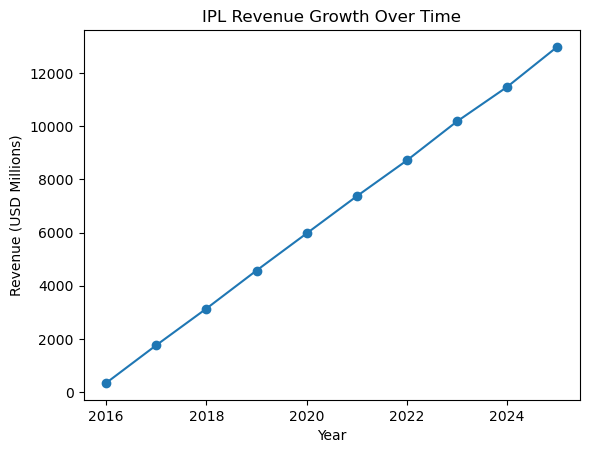

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ipl_financial['Year'], ipl_financial['Revenue_USD_M'], marker='o')
plt.title("IPL Revenue Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (USD Millions)")
plt.show()

### Insight
Revenue is increasing over the years, showing strong growth of the league.

# 📊  Growth Rate

In [8]:
ipl_financial = financial[financial['League'] == 'IPL'].copy().reset_index(drop=True)
ipl_financial['Revenue_Growth_%'] = ipl_financial['Revenue_USD_M'].pct_change() * 100
ipl_financial[['Year', 'Revenue_USD_M', 'Revenue_Growth_%']]

,Year,Revenue_USD_M,Revenue_Growth_%
0,2016,346.9,NaN
1,2017,1765.3,408.878639
2,2018,3141.1,77.935762
3,2019,4571.5,45.538187
4,2020,5966.0,30.504211
5,2021,7362.9,23.414348
6,2022,8708.6,18.276766
7,2023,10173.6,16.822451
8,2024,11470.7,12.749666
9,2025,12976.4,13.126487


## 🏏 Match Analysis

In this section, we explore match-level data to understand factors that influence audience engagement.

In [9]:
matches.head()

,League,Season_Year,Match_Number,Team1,Team2,Team1_Score,Team2_Score,Winner,Margin_Runs,Team1_Sixes,Team2_Sixes,Total_Sixes,Venue_City,Is_Day_Night,Attendance
0,IPL,2016,1,SRH,CSK,199,177,SRH,22,11,12,23,Mumbai,True,43140
1,IPL,2016,2,CSK,RCB,165,185,RCB,20,8,0,8,Kolkata,True,57764
2,IPL,2016,3,GT,CSK,169,132,GT,37,5,5,10,Mumbai,True,54484
3,IPL,2016,4,GT,SRH,176,169,GT,7,9,12,21,Bengaluru,True,45801
4,IPL,2016,5,RCB,LSG,179,172,RCB,7,10,4,14,Kolkata,False,46225


In [10]:
matches.columns


Index(['League', 'Season_Year', 'Match_Number', 'Team1', 'Team2',
       'Team1_Score', 'Team2_Score', 'Winner', 'Margin_Runs', 'Team1_Sixes',
       'Team2_Sixes', 'Total_Sixes', 'Venue_City', 'Is_Day_Night',
       'Attendance'],
      dtype='object')

In [11]:
matches[['Total_Sixes', 'Attendance']].head()

,Total_Sixes,Attendance
0,23,43140
1,8,57764
2,10,54484
3,21,45801
4,14,46225


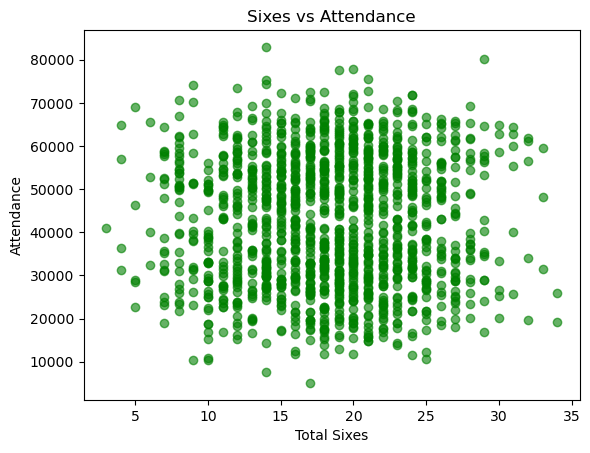

In [12]:
plt.figure()
plt.scatter(matches['Total_Sixes'], matches['Attendance'], color='green', alpha=0.6)
plt.title("Sixes vs Attendance")
plt.xlabel("Total Sixes")
plt.ylabel("Attendance")
plt.show()

# Compare High vs Low Sixes

In [13]:
high_six = matches[matches['Total_Sixes'] > 20]
low_six = matches[matches['Total_Sixes'] <= 20]

high_six['Attendance'].mean(), low_six['Attendance'].mean()

(42707.66265060241, 42416.11751662971)

### Insight

Matches with higher number of sixes tend to have slightly higher average attendance compared to matches with fewer sixes.

This suggests that more aggressive and entertaining gameplay may attract more audience.

In [14]:
matches['Total_Sixes'].corr(matches['Attendance'])

0.008948340699074431

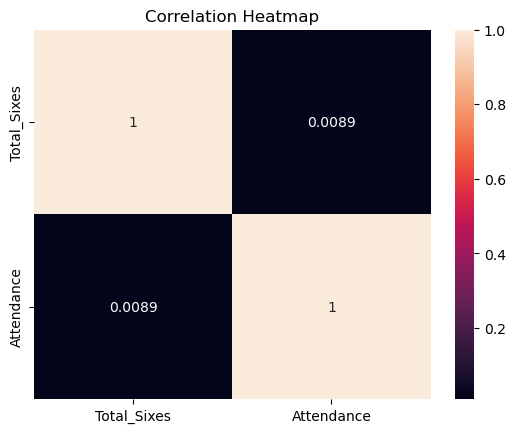

In [15]:
import seaborn as sns

corr = matches[['Total_Sixes', 'Attendance']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Insight

The correlation between total sixes and attendance is very close to zero (~0.009), indicating no meaningful relationship.

This suggests that the number of sixes in a match does not significantly influence audience attendance.



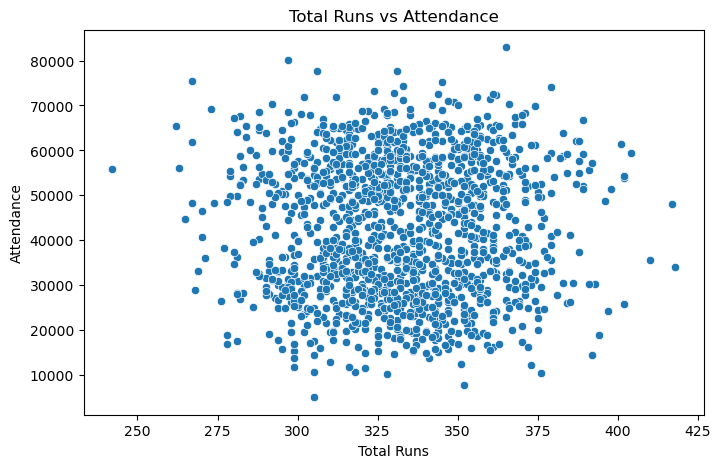

In [16]:
matches['Total_Runs'] = matches['Team1_Score'] + matches['Team2_Score']

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=matches['Total_Runs'],
    y=matches['Attendance']
)

plt.title("Total Runs vs Attendance")
plt.xlabel("Total Runs")
plt.ylabel("Attendance")

plt.show()

### Insight

Matches with higher total runs tend to attract greater audience attendance, indicating that high-scoring games contribute to increased fan engagement.

## 🏏 Team Performance Analysis

In this section, we analyze team performance and evaluate how efficiently teams perform relative to their value.

In [17]:
teams.head()

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City
0,IPL,MI,India,5,7,18,47.5,209.0,Mumbai
1,IPL,CSK,India,5,7,18,43.0,115.8,Chennai
2,IPL,RCB,India,1,2,18,62.6,185.4,Bengaluru
3,IPL,KKR,India,3,4,18,58.7,176.2,Kolkata
4,IPL,DC,India,0,0,18,56.3,235.0,Delhi


In [18]:
teams.columns

Index(['League', 'Team', 'Country', 'Titles_Won', 'Finals_Played',
       'Total_Seasons', 'Approx_Win_Rate_Pct', 'Est_Team_Value_USD_M',
       'Home_City'],
      dtype='object')

# 🏏 Team Performance by League

In [19]:
teams[['Team', 'Approx_Win_Rate_Pct']].head()

,Team,Approx_Win_Rate_Pct
0,MI,47.5
1,CSK,43.0
2,RCB,62.6
3,KKR,58.7
4,DC,56.3


In [20]:
teams[teams['League'] == 'IPL'].sort_values(by='Approx_Win_Rate_Pct', ascending=False)

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City
6,IPL,RR,India,0,0,18,62.9,176.3,Jaipur
2,IPL,RCB,India,1,2,18,62.6,185.4,Bengaluru
3,IPL,KKR,India,3,4,18,58.7,176.2,Kolkata
9,IPL,LSG,India,0,1,4,57.4,282.9,Lucknow
4,IPL,DC,India,0,0,18,56.3,235.0,Delhi
7,IPL,PBKS,India,0,1,18,49.3,208.0,Mohali
0,IPL,MI,India,5,7,18,47.5,209.0,Mumbai
5,IPL,SRH,India,1,2,18,45.2,104.4,Hyderabad
1,IPL,CSK,India,5,7,18,43.0,115.8,Chennai
8,IPL,GT,India,1,1,4,42.3,178.9,Ahmedabad


In [21]:
teams[teams['League'] == 'PSL'].sort_values(by='Approx_Win_Rate_Pct', ascending=False)

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City
15,PSL,Multan Sultans,Pakistan,1,2,10,60.0,36.6,Multan
13,PSL,Quetta Gladiators,Pakistan,1,2,10,54.6,75.5,Quetta
14,PSL,Peshawar Zalmi,Pakistan,1,2,10,54.6,54.1,Peshawar
11,PSL,Lahore Qalandars,Pakistan,3,4,10,48.6,79.0,Lahore
12,PSL,Islamabad United,Pakistan,3,4,10,47.1,55.4,Islamabad
10,PSL,Karachi Kings,Pakistan,1,2,10,39.0,60.6,Karachi


In [22]:
teams[teams['League'] == 'BBL'].sort_values(by='Approx_Win_Rate_Pct', ascending=False)

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City
17,BBL,Sydney Thunder,Australia,1,1,14,59.1,19.8,Sydney
16,BBL,Sydney Sixers,Australia,3,4,14,55.6,18.5,Sydney
22,BBL,Brisbane Heat,Australia,2,2,14,55.5,58.8,Brisbane
20,BBL,Perth Scorchers,Australia,6,6,14,51.6,34.8,Perth
23,BBL,Hobart Hurricanes,Australia,1,1,14,51.5,49.6,Hobart
18,BBL,Melbourne Stars,Australia,0,1,14,47.6,59.5,Melbourne
21,BBL,Adelaide Strikers,Australia,1,1,14,46.8,45.2,Adelaide
19,BBL,Melbourne Renegades,Australia,1,1,14,40.7,18.0,Melbourne


# 💰 Team Performance vs Value Analysis

🏏 IPL

In [23]:
ipl_teams = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .query("League == 'IPL'")
    .sort_values(by='Efficiency', ascending=False)
    .reset_index(drop=True)
)

ipl_teams

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City,Efficiency
0,IPL,SRH,India,1,2,18,45.2,104.4,Hyderabad,0.432950
1,IPL,CSK,India,5,7,18,43.0,115.8,Chennai,0.371330
2,IPL,RR,India,0,0,18,62.9,176.3,Jaipur,0.356778
3,IPL,RCB,India,1,2,18,62.6,185.4,Bengaluru,0.337648
4,IPL,KKR,India,3,4,18,58.7,176.2,Kolkata,0.333144
5,IPL,DC,India,0,0,18,56.3,235.0,Delhi,0.239574
6,IPL,PBKS,India,0,1,18,49.3,208.0,Mohali,0.237019
7,IPL,GT,India,1,1,4,42.3,178.9,Ahmedabad,0.236445
8,IPL,MI,India,5,7,18,47.5,209.0,Mumbai,0.227273
9,IPL,LSG,India,0,1,4,57.4,282.9,Lucknow,0.202899


🏏 PSL

In [24]:
psl_teams = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .query("League == 'PSL'")
    .sort_values(by='Efficiency', ascending=False)
    .reset_index(drop=True)
)

psl_teams

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City,Efficiency
0,PSL,Multan Sultans,Pakistan,1,2,10,60.0,36.6,Multan,1.639344
1,PSL,Peshawar Zalmi,Pakistan,1,2,10,54.6,54.1,Peshawar,1.009242
2,PSL,Islamabad United,Pakistan,3,4,10,47.1,55.4,Islamabad,0.850181
3,PSL,Quetta Gladiators,Pakistan,1,2,10,54.6,75.5,Quetta,0.723179
4,PSL,Karachi Kings,Pakistan,1,2,10,39.0,60.6,Karachi,0.643564
5,PSL,Lahore Qalandars,Pakistan,3,4,10,48.6,79.0,Lahore,0.615190


🏏 BBL

In [25]:
bbl_teams = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .query("League == 'BBL'")
    .sort_values(by='Efficiency', ascending=False)
    .reset_index(drop=True)
)

bbl_teams

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City,Efficiency
0,BBL,Sydney Sixers,Australia,3,4,14,55.6,18.5,Sydney,3.005405
1,BBL,Sydney Thunder,Australia,1,1,14,59.1,19.8,Sydney,2.984848
2,BBL,Melbourne Renegades,Australia,1,1,14,40.7,18.0,Melbourne,2.261111
3,BBL,Perth Scorchers,Australia,6,6,14,51.6,34.8,Perth,1.482759
4,BBL,Hobart Hurricanes,Australia,1,1,14,51.5,49.6,Hobart,1.038306
5,BBL,Adelaide Strikers,Australia,1,1,14,46.8,45.2,Adelaide,1.035398
6,BBL,Brisbane Heat,Australia,2,2,14,55.5,58.8,Brisbane,0.943878
7,BBL,Melbourne Stars,Australia,0,1,14,47.6,59.5,Melbourne,0.800000


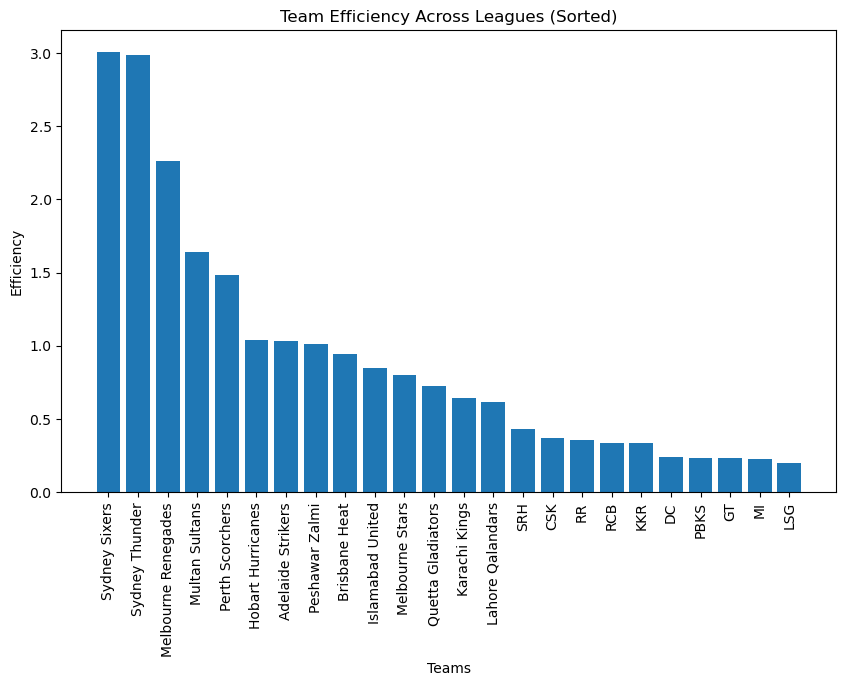

In [26]:
plt.figure(figsize=(10,6))

# Create Efficiency + sort
sorted_teams = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .sort_values(by='Efficiency', ascending=False)
    .reset_index(drop=True)
)

# Plot
plt.bar(sorted_teams['Team'], sorted_teams['Efficiency'])

plt.title("Team Efficiency Across Leagues (Sorted)")
plt.xlabel("Teams")
plt.ylabel("Efficiency")

plt.xticks(rotation=90)

plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_5780\1708690897.py:35: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
C:\Users\shubh\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


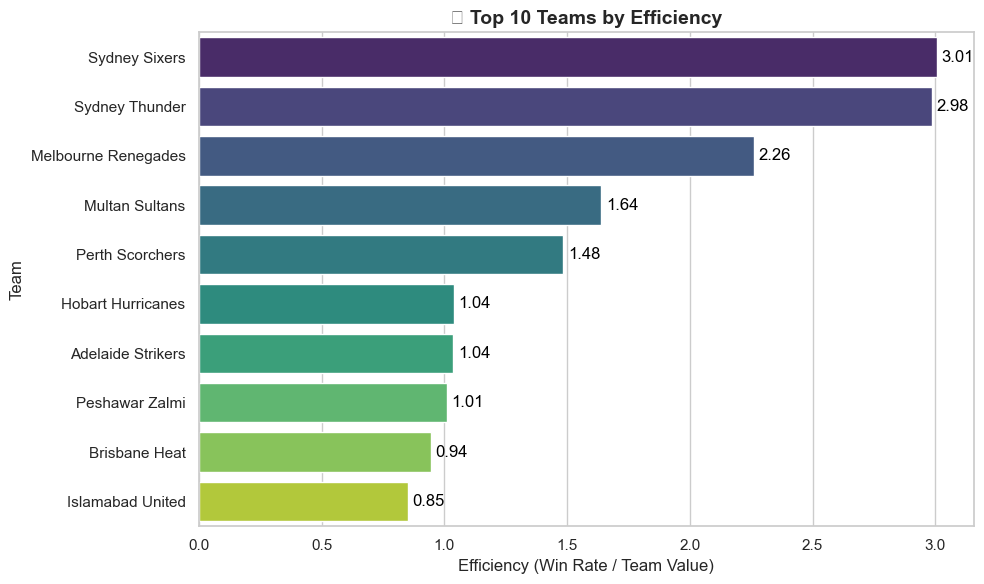

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Style
sns.set_style("whitegrid")
sns.set_context("notebook")

# Create Efficiency + sort + limit (top 10 for clarity)
sorted_teams = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .sort_values(by='Efficiency', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x='Efficiency',
    y='Team',
    data=sorted_teams,
    palette='viridis'
)

# Add values on bars
for i, value in enumerate(sorted_teams['Efficiency']):
    ax.text(value + 0.02, i, f"{value:.2f}", color='black', va='center')

plt.title("🔥 Top 10 Teams by Efficiency", fontsize=14, fontweight='bold')
plt.xlabel("Efficiency (Win Rate / Team Value)")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

## 📌 Key Takeaways

- The most efficient team achieves an efficiency of approximately **3.00**, indicating very high performance relative to its value.
- In contrast, several teams show efficiency values below **0.30**, suggesting lower return on investment.
- The gap between top-performing and low-performing teams is significant, with efficiency ranging from **~0.20 to ~3.00**.
- Teams with moderate valuations but strong win rates tend to achieve higher efficiency, highlighting better resource utilization.

Overall, efficiency analysis reveals that higher spending does not always translate into better performance, emphasizing the importance of strategic team management.

## 🏏 Player Salary Analysis

In this section, we analyze player salaries to understand spending patterns across teams, roles, and categories.

In [28]:
players.head()

,League,Auction_Year,Season_Year,Player_Name,Team,Nationality,Role,Bid_Price_INR_Cr,Salary_Cap_INR_Cr,Category,Is_Overseas
0,IPL,2016,2016,Shane Watson,CSK,AUS,Batsman,9.5,9.5,Top Buy,True
1,IPL,2017,2017,Ben Stokes,RPS,ENG,All-rounder,14.5,14.5,Top Buy,True
2,IPL,2018,2018,Ben Stokes,RR,ENG,All-rounder,12.5,12.5,Top Buy,True
3,IPL,2019,2019,Jaydev Unadkat,RR,IND,Bowler,8.4,8.4,Top Buy,False
4,IPL,2020,2020,Pat Cummins,KKR,AUS,Bowler,15.5,15.5,Top Buy,True


In [29]:
players.columns

Index(['League', 'Auction_Year', 'Season_Year', 'Player_Name', 'Team',
       'Nationality', 'Role', 'Bid_Price_INR_Cr', 'Salary_Cap_INR_Cr',
       'Category', 'Is_Overseas'],
      dtype='object')

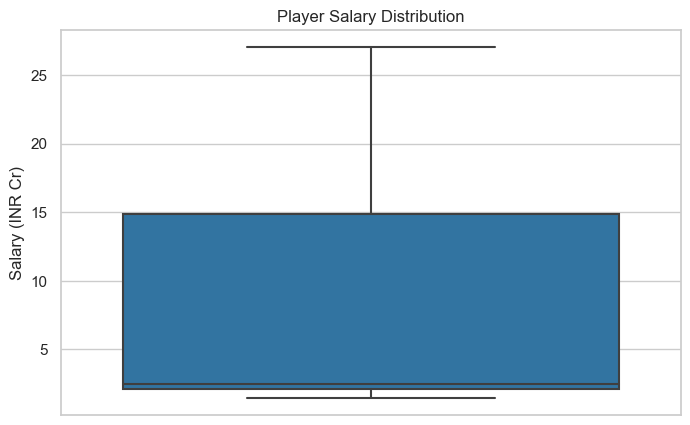

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=players['Bid_Price_INR_Cr']
)

plt.title("Player Salary Distribution")
plt.ylabel("Salary (INR Cr)")

plt.show()

### Insight

The salary distribution shows a wide spread with several high-value outliers, indicating that a small number of players receive significantly higher bids compared to the majority.

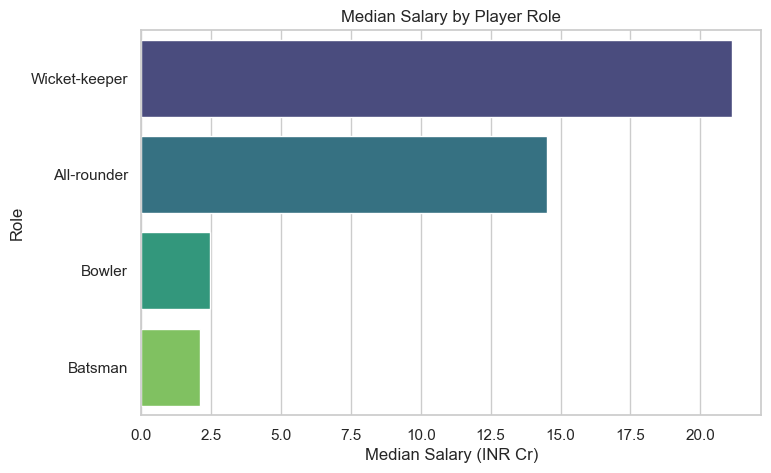

In [31]:
plt.figure(figsize=(8,5))

# Use median instead of mean
role_salary = players.groupby('Role')['Bid_Price_INR_Cr'].median().sort_values(ascending=False)

sns.barplot(
    x=role_salary.values,
    y=role_salary.index,
    palette='viridis'
)

plt.title("Median Salary by Player Role")
plt.xlabel("Median Salary (INR Cr)")
plt.ylabel("Role")

plt.show()

### Insight

Using median salary provides a more reliable comparison across roles by reducing the impact of a few highly paid star players.
This shows the typical salary distribution for each role more accurately.

Average was misleading, so median was used for fair comparison.

🔥 1. Market Concentration 

👉 Question:
Are teams spending most money on a few players?

In [32]:
top_10 = players.sort_values(by='Bid_Price_INR_Cr', ascending=False).head(10)

top_10_sum = top_10['Bid_Price_INR_Cr'].sum()
total_sum = players['Bid_Price_INR_Cr'].sum()

(top_10_sum / total_sum) * 100

83.98196487897485

A significant percentage of total spending is concentrated on the top 10 players, indicating a star-driven market where a few players dominate auction budgets.

# 🔥 2. Team Spending Strategy

👉 Question:
Which teams spend aggressively vs evenly?

In [33]:
team_spending = players.groupby('Team')['Bid_Price_INR_Cr'].sum().sort_values(ascending=False)
team_spending

Team
KKR                 65.45
LSG                 27.00
RR                  20.90
PBKS                18.50
MI                  15.25
RPS                 14.50
RCB                 14.25
CSK                  9.50
Sydney Thunder       7.70
Lahore Qalandars     4.55
Peshawar Zalmi       4.55
Sydney Sixers        4.45
Karachi Kings        4.10
Name: Bid_Price_INR_Cr, dtype: float64

Some teams allocate significantly higher budgets compared to others, indicating aggressive bidding strategies, while others follow a more balanced spending approach.

# 🔥 3. Role-Based Investment Strategy

👉 Question:

Where are teams investing most?

In [34]:
role_spending = players.groupby('Role')['Bid_Price_INR_Cr'].sum().sort_values(ascending=False)
role_spending

Role
All-rounder      84.95
Bowler           57.65
Wicket-keeper    42.25
Batsman          25.85
Name: Bid_Price_INR_Cr, dtype: float64

Certain roles attract higher total investment, indicating their perceived importance in team composition and match outcomes.

## 🔍 Advanced Player Market Analysis

In this section, we go beyond basic salary distribution to analyze how player auctions reflect market dynamics and team strategies.

We explore:
- How spending is concentrated among top players
- How teams allocate their budgets
- Which roles attract the highest investment

This helps in understanding whether the player market is balanced or driven by a few high-value players, and how teams approach bidding strategically.

In [35]:
top_10 = players.sort_values(by='Bid_Price_INR_Cr', ascending=False).head(10)

top_10_sum = top_10['Bid_Price_INR_Cr'].sum()
total_sum = players['Bid_Price_INR_Cr'].sum()

(top_10_sum / total_sum) * 100

83.98196487897485

### 💰 Market Concentration Insight

The top 10 players account for approximately **84% of the total auction spending**.

This indicates a highly concentrated market where a small number of players dominate the majority of the budget.

Such a distribution suggests a **star-driven auction strategy**, where teams prioritize acquiring a few high-impact players over building a uniformly balanced squad.

## 👉 Team Spending Strategy

In [36]:
team_spending = players.groupby('Team')['Bid_Price_INR_Cr'].sum().sort_values(ascending=False)
team_spending

Team
KKR                 65.45
LSG                 27.00
RR                  20.90
PBKS                18.50
MI                  15.25
RPS                 14.50
RCB                 14.25
CSK                  9.50
Sydney Thunder       7.70
Lahore Qalandars     4.55
Peshawar Zalmi       4.55
Sydney Sixers        4.45
Karachi Kings        4.10
Name: Bid_Price_INR_Cr, dtype: float64

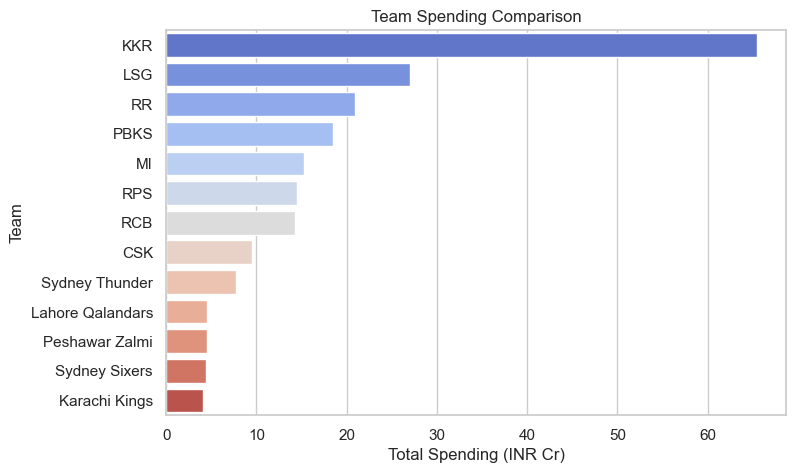

In [37]:
plt.figure(figsize=(8,5))

team_spending_sorted = team_spending

sns.barplot(
    x=team_spending_sorted.values,
    y=team_spending_sorted.index,
    palette='coolwarm'
)

plt.title("Team Spending Comparison")
plt.xlabel("Total Spending (INR Cr)")
plt.ylabel("Team")

plt.show()

### 💰 Team Spending Insight

Kolkata Knight Riders (KKR) has the highest total spending at approximately **65.45 Cr**, which is significantly higher than the next highest team, Lucknow Super Giants (LSG) at **27.00 Cr**.

This large gap indicates an **aggressive bidding strategy** by KKR, allocating a substantial portion of their budget toward player acquisition.

In contrast, other teams show relatively moderate spending, suggesting more balanced or conservative investment approaches.

In [38]:
role_spending = players.groupby('Role')['Bid_Price_INR_Cr'].sum().sort_values(ascending=False)
role_spending

Role
All-rounder      84.95
Bowler           57.65
Wicket-keeper    42.25
Batsman          25.85
Name: Bid_Price_INR_Cr, dtype: float64

### 🎯 Role Investment Insight

All-rounders receive the highest total investment at approximately **84.95 Cr**, followed by bowlers at **57.65 Cr**.

Wicket-keepers and batsmen receive comparatively lower total spending, with batsmen having the lowest at **25.85 Cr**.

This indicates that teams prioritize **versatile players (all-rounders)** who can contribute in multiple aspects of the game, making them more valuable in auction strategies.

Overall, investment patterns suggest that **flexibility and multi-skill capability are highly valued** in team composition.

## 🧠 Deep Performance Analysis

In this section, we move beyond individual metrics to understand what truly differentiates successful teams from others.

Rather than analyzing factors in isolation, we examine the relationship between:
- Team performance (titles and win rate)
- Financial investment (team value and spending)
- Efficiency (performance relative to cost)
- Experience (number of seasons played)

The goal is to identify whether success is driven by higher spending, better efficiency, or strategic team composition.

In [39]:
teams.sort_values(by='Titles_Won', ascending=False).reset_index(drop=True)

,League,Team,Country,Titles_Won,Finals_Played,Total_Seasons,Approx_Win_Rate_Pct,Est_Team_Value_USD_M,Home_City
0,BBL,Perth Scorchers,Australia,6,6,14,51.6,34.8,Perth
1,IPL,MI,India,5,7,18,47.5,209.0,Mumbai
2,IPL,CSK,India,5,7,18,43.0,115.8,Chennai
3,PSL,Lahore Qalandars,Pakistan,3,4,10,48.6,79.0,Lahore
4,BBL,Sydney Sixers,Australia,3,4,14,55.6,18.5,Sydney
5,PSL,Islamabad United,Pakistan,3,4,10,47.1,55.4,Islamabad
6,IPL,KKR,India,3,4,18,58.7,176.2,Kolkata
7,BBL,Brisbane Heat,Australia,2,2,14,55.5,58.8,Brisbane
8,PSL,Multan Sultans,Pakistan,1,2,10,60.0,36.6,Multan
9,PSL,Peshawar Zalmi,Pakistan,1,2,10,54.6,54.1,Peshawar


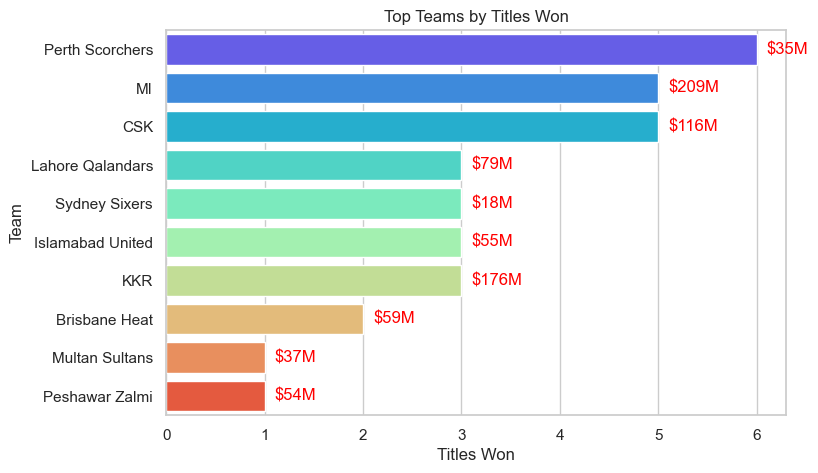

In [40]:
plt.figure(figsize=(8,5))

top_teams = teams.sort_values(by='Titles_Won', ascending=False).head(10).reset_index(drop=True)

ax = sns.barplot(
    x='Titles_Won',
    y='Team',
    data=top_teams,
    palette='rainbow'
)

# Add value labels
for i, value in enumerate(top_teams['Est_Team_Value_USD_M']):
    ax.text(
        top_teams.loc[i, 'Titles_Won'] + 0.1,
        i,
        f"${value:.0f}M",
        color='red',
        va='center'
    )

plt.title("Top Teams by Titles Won")
plt.xlabel("Titles Won")
plt.ylabel("Team")

plt.show()

### 🧠 Performance vs Investment Insight

The chart compares team performance (titles won) with their financial strength (team value).

While several teams have achieved similar success in terms of titles, their investment levels vary significantly. For example, some teams have achieved high success with relatively lower team valuation, while others have required substantially higher investment to reach similar outcomes.

This highlights that **success is not solely driven by financial strength**, but by how effectively resources are utilized.

In particular, teams achieving high titles with lower valuation demonstrate **greater efficiency and stronger strategic execution**, making them more effective in converting investment into results.

# Efficiency vs Titles

Do efficient teams actually win more?

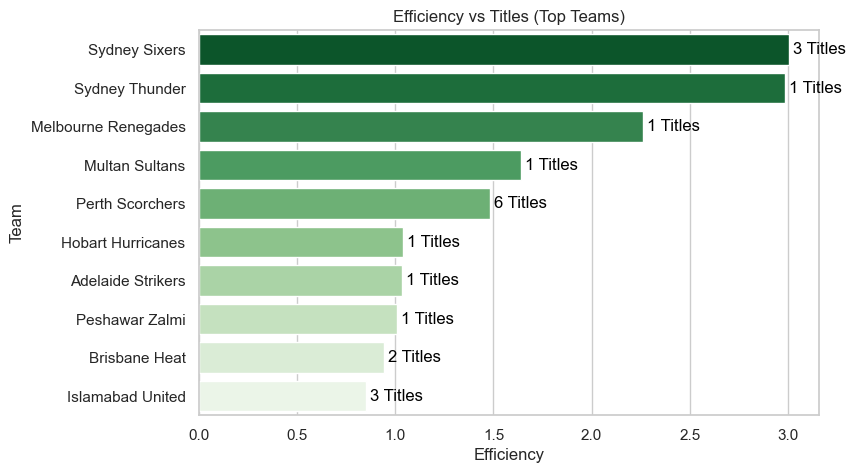

In [41]:
plt.figure(figsize=(8,5))

top_eff = (
    teams
    .assign(Efficiency = teams['Approx_Win_Rate_Pct'] / teams['Est_Team_Value_USD_M'])
    .sort_values(by='Efficiency', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

ax = sns.barplot(
    x='Efficiency',
    y='Team',
    data=top_eff,
    palette='Greens_r'
)

# Add Titles on bars
for i, val in enumerate(top_eff['Titles_Won']):
    ax.text(
        top_eff.loc[i, 'Efficiency'] + 0.02,
        i,
        f"{val} Titles",
        color='black',
        va='center'
    )

plt.title("Efficiency vs Titles (Top Teams)")
plt.xlabel("Efficiency")
plt.ylabel("Team")

plt.show()

### 🧠 Titles vs Efficiency Insight

The comparison between titles and efficiency shows that the most successful teams are not always the most efficient.

Some teams achieve a high number of titles despite lower efficiency, indicating reliance on higher financial investment.

In contrast, other teams demonstrate strong efficiency with fewer titles, suggesting better resource utilization and cost-effectiveness.

This highlights that success and efficiency are related but distinct dimensions. While high spending can drive short-term success, long-term dominance depends on achieving a balance between performance and efficient use of resources.

## ⚙️ Feature Engineering

To enhance the analysis, additional features were created to better capture performance and market dynamics:

- **Revenue Growth %** → Measures league growth over time  
- **Team Efficiency** → Win Rate / Team Value (captures cost-effectiveness)  
- **Total Runs** → Combined score of both teams (match intensity)

### New Feature: Match Competitiveness
- Defined as the absolute difference between team scores
- Helps understand how close or one-sided matches are

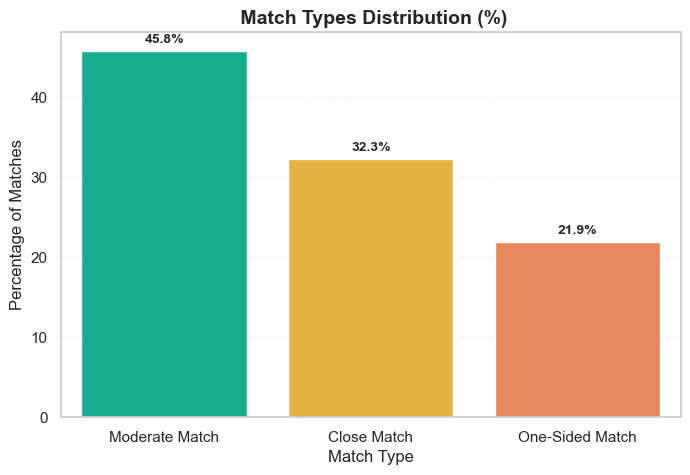

In [42]:
# Create categories
def categorize_match(diff):
    if diff <= 10:
        return "Close Match"
    elif diff <= 30:
        return "Moderate Match"
    else:
        return "One-Sided Match"

matches['Match_Competitiveness'] = abs(matches['Team1_Score'] - matches['Team2_Score'])
matches['Match_Type'] = matches['Match_Competitiveness'].apply(categorize_match)

# Percentage distribution
match_percent = matches['Match_Type'].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(8,5))

colors = ['#00C49F', '#FFBB28', '#FF8042']  # green, yellow, orange

ax = sns.barplot(
    x=match_percent.index,
    y=match_percent.values,
    palette=colors
)

# Add % labels
for i, value in enumerate(match_percent.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.title(" Match Types Distribution (%)", fontsize=14, fontweight='bold')
plt.xlabel("Match Type")
plt.ylabel("Percentage of Matches")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 🔥 “Do close matches attract more audience?”


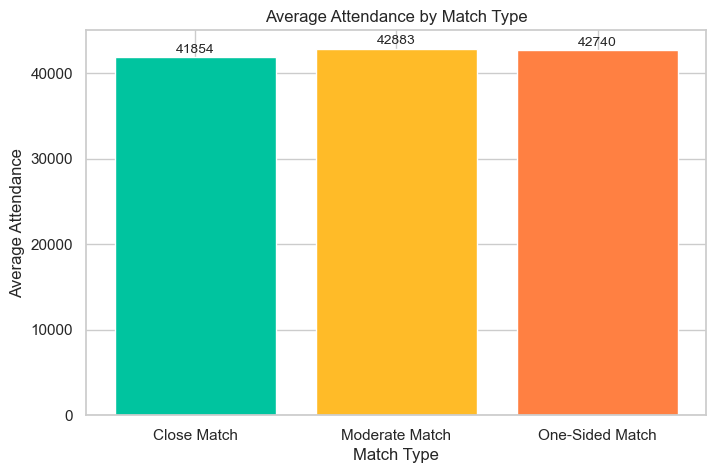

In [43]:
# Average attendance per match type
avg_attendance = matches.groupby('Match_Type')['Attendance'].mean()

plt.figure(figsize=(8,5))

colors = ['#00C49F', '#FFBB28', '#FF8042']

plt.bar(
    avg_attendance.index,
    avg_attendance.values,
    color=colors
)

# Add values
for i, value in enumerate(avg_attendance.values):
    plt.text(i, value + 500, f"{int(value)}", ha='center', fontsize=10)

plt.title("Average Attendance by Match Type")
plt.xlabel("Match Type")
plt.ylabel("Average Attendance")

plt.show()

### Insight

The average attendance across match types is very similar, with only minor differences between close, moderate, and one-sided matches.

This suggests that match competitiveness does not significantly influence attendance.

Attendance is likely driven more by factors such as team popularity, venue, and scheduling rather than how close the match turns out to be.

# Which teams bring more audience?

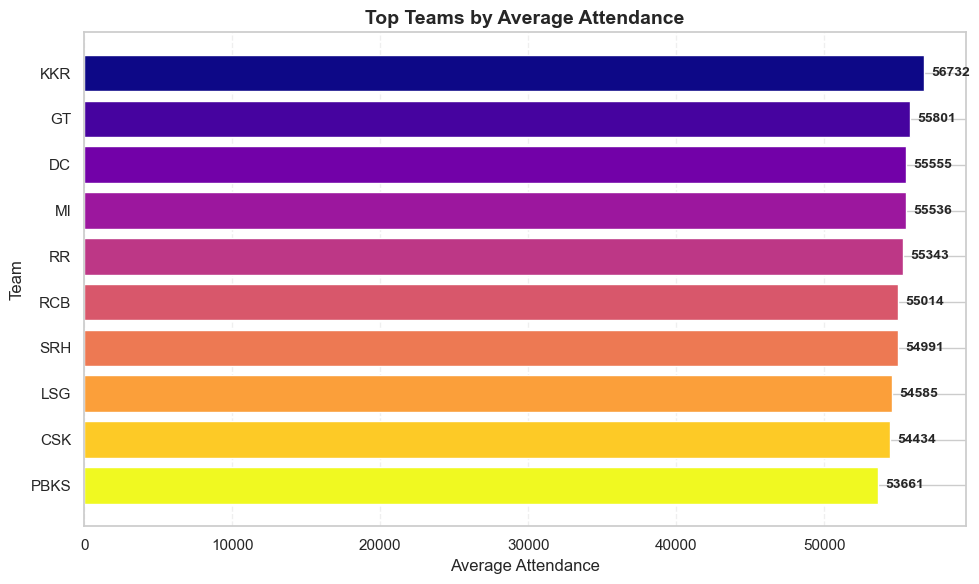

In [48]:
import numpy as np

team_attendance = matches.groupby('Team1')['Attendance'].mean().sort_values(ascending=False)

top_teams = team_attendance.head(10).reset_index()

plt.figure(figsize=(10,6))

# Proper gradient colors
colors = plt.cm.plasma(np.linspace(0, 1, len(top_teams)))

bars = plt.barh(
    top_teams['Team1'],
    top_teams['Attendance'],
    color=colors
)

# Add values
for i, value in enumerate(top_teams['Attendance']):
    plt.text(
        value + 500,
        i,
        f"{int(value)}",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Top Teams by Average Attendance", fontsize=14, fontweight='bold')
plt.xlabel("Average Attendance")
plt.ylabel("Team")

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 🧠 Stakeholder Insight: Team Popularity & Audience Engagement

The analysis shows a clear variation in average attendance across teams, indicating that certain teams consistently attract larger audiences.

#### 📈 Key Observations

- A few teams dominate in terms of attendance, suggesting strong brand value and fan following.
- Lower-performing teams attract comparatively fewer spectators, indicating weaker market presence.

#### 🎯 Strategic Implications

**For High-Attendance Teams:**
- Leverage strong fan base for premium ticket pricing and sponsorship opportunities.
- Focus on maintaining performance and star players to sustain audience interest.

**For Low-Attendance Teams:**
- Invest in brand building and fan engagement strategies.
- Improve on-field performance to increase visibility and interest.
- Target local market activation and promotions to boost stadium turnout.

#### 💡 Business Insight

Attendance is driven more by team popularity and brand value than by match outcomes alone. Teams with strong identity and consistent performance are better positioned to generate higher engagement and revenue.

## ⚠️ Limitations

- Player performance data (runs, wickets) is not available, limiting performance-based evaluation.
- Attendance data does not capture external factors such as weather, scheduling, or ticket pricing.
- Analysis is based on aggregated metrics, which may hide match-level variations.

## 📌 Key Takeaways

- Team popularity is the strongest driver of attendance.
- Match competitiveness has minimal impact on audience turnout.
- Efficient teams are not always the most successful, indicating different strategic approaches.
- Spending strategy varies significantly across teams and leagues.

# 📌 Final Conclusion

This analysis explored the growth, performance, and engagement dynamics across major T20 leagues, focusing on revenue trends, match characteristics, team strategies, and player investments.

Key findings reveal that league growth has been strong, driven by increasing revenues and expanding audience interest. However, match-level factors such as competitiveness and scoring have limited influence on attendance, indicating that fan engagement is not solely driven by on-field outcomes.

Instead, team-related factors play a more significant role. Teams with strong brand value, consistent performance, and established fan bases attract higher attendance and engagement. Additionally, the analysis shows that success and efficiency are not always aligned, as some teams achieve higher titles through greater investment, while others demonstrate better resource utilization with fewer trophies.

From a strategic perspective, long-term success in these leagues requires a balance between financial investment, team composition, and efficient resource management. Teams that combine strong performance with smart spending and brand building are better positioned to achieve sustained dominance.

Overall, this study highlights that in modern T20 leagues, success extends beyond the game itself — it is shaped by a combination of performance, strategy, and market-driven factors.


Analysis By:
Shubham Kulkarni